# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [4]:
import tensorflow as tf

In [5]:
checkpoints = r'C:\Users\User\anaconda3\envs\first_env\Lab_11\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [6]:
train_dir = r'D:\New folder\archive(4)\computer vision\train'
validation_dir = r'D:\New folder\archive(4)\computer vision\validation'
test_dir = r'D:\New folder\archive(4)\computer vision\test'

In [7]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(64, 64, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
# model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1,activation='sigmoid'))

c:\Users\User\anaconda3\envs\first_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,033 (1.42 MB)

 Trainable params: 372,033 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['acc']
)



In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(64, 64), batch_size=32,class_mode='binary')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(64, 64),batch_size=32,class_mode='binary')

Found 240 images belonging to 2 classes.
Found 93 images belonging to 2 classes.


In [11]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [13]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=5,
                    callbacks=callbacks)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - acc: 0.5414 - loss: 0.6741
Epoch 1: val_loss improved from 0.68090 to 0.65925, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_11\\E1-cp-0001-loss0.66.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - acc: 0.5429 - loss: 0.6743 - val_acc: 0.7527 - val_loss: 0.6593
Epoch 2/5
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - acc: 0.5625 - loss: 0.6766
Epoch 2: val_loss did not improve from 0.65925
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5625 - loss: 0.6766 - val_acc: 0.3548 - val_loss: 0.7091
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.5802 - loss: 0.6606
Epoch 3: val_loss did not improve from 0.65925
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - acc: 0.5786 - loss: 0.6606 - val_acc: 0.6344 - val_loss: 0.6719
Epoch 4/5
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - acc: 0.6875 - loss: 0.6621
Epoch 4: val_loss did not improve from 0.65925
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.6875 - loss: 0.6621 - val_acc: 0.4839 - val_loss: 0.6866
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - acc: 0.6565 - loss: 0.6471
Epoch 5: val_loss improved from 0.65925 to 0.64642, saving model to C:\Users\User\anaconda3\envs\first_env\Lab_11\\E1-cp-0005-los

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - acc: 0.6519 - loss: 0.6483 - val_acc: 0.7742 - val_loss: 0.6464


In [14]:
model_history.history

{'acc': [0.5528846383094788,
  0.5625,
  0.567307710647583,
  0.6875,
  0.620192289352417],
 'loss': [0.6752482056617737,
  0.676632285118103,
  0.6605243682861328,
  0.662084698677063,
  0.6564697027206421],
 'val_acc': [0.7526881694793701,
  0.35483869910240173,
  0.6344085931777954,
  0.4838709533214569,
  0.774193525314331],
 'val_loss': [0.6592503190040588,
  0.7090549468994141,
  0.6719074249267578,
  0.6865510940551758,
  0.6464173793792725]}

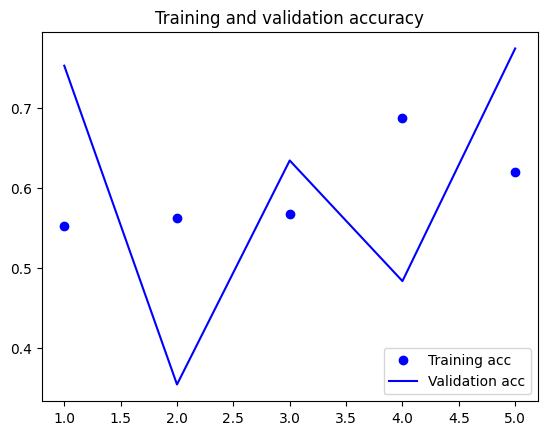

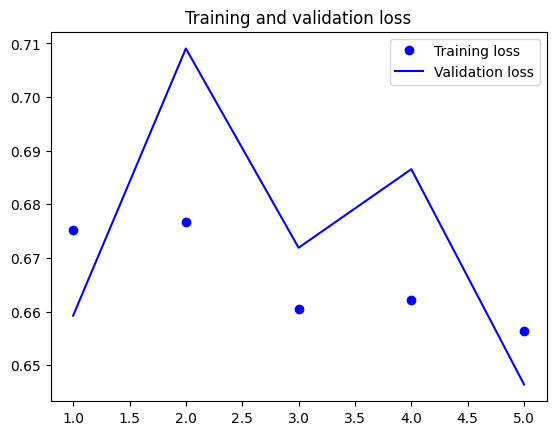

In [15]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_Accuracy.png')

In [12]:
#model.save(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab12\E1-cp-0012-loss0.21.h5')

Found 20 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step


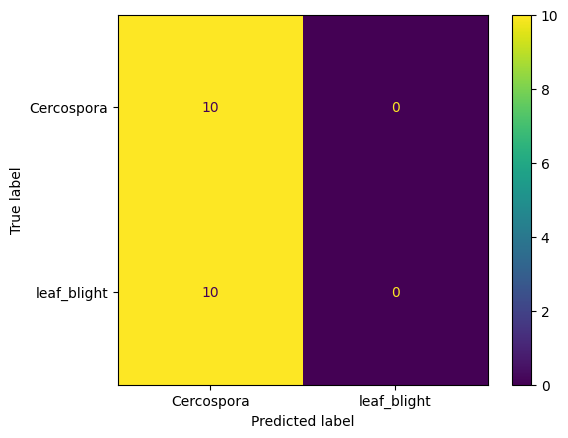

In [16]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(64, 64), batch_size=32, shuffle=False, class_mode='binary')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [17]:
print(classification_report(label, pred, target_names=['Cercospora', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.50      1.00      0.67        10
 leaf_blight       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



c:\Users\User\anaconda3\envs\first_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\first_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\first_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res